In [11]:
import pandas as pd


In [12]:
df = pd.read_csv("US_Accidents_Dec20_Updated.csv")  
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15072\1564035920.py:1: DtypeWarning: Columns (0: Amenity, 1: Bump, 2: Crossing, 3: Give_Way, 4: Junction, 5: No_Exit, 6: Railway, 7: Roundabout, 8: Station, 9: Stop, 10: Traffic_Calming, 11: Traffic_Signal, 12: Turning_Loop) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("US_Accidents_Dec20_Updated.csv")


,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,2,2019-05-21 08:29:55,2019-05-21 09:29:40,34.808868,-82.269157,34.808868,-82.269157,0.0,Accident on Tanner Rd at Pennbrooke Ln.,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-2,2,2019-10-07 17:43:09,2019-10-07 19:42:50,35.090080,-80.745560,35.090080,-80.745560,0.0,Accident on Houston Branch Rd at Providence Br...,...,False,False,False,False,False,False,Day,Day,Day,Day
2,A-3,2,2020-12-13 21:53:00,2020-12-13 22:44:00,37.145730,-121.985052,37.165850,-121.988062,1.4,Stationary traffic on CA-17 from Summit Rd (CA...,...,False,False,False,False,False,False,Night,Night,Night,Night
3,A-4,2,2018-04-17 16:51:23,2018-04-17 17:50:46,39.110390,-119.773781,39.110390,-119.773781,0.0,Accident on US-395 Southbound at Topsy Ln.,...,False,False,False,False,True,False,Day,Day,Day,Day
4,A-5,3,2016-08-31 17:40:49,2016-08-31 18:10:49,26.102942,-80.265091,26.102942,-80.265091,0.0,Accident on I-595 Westbound at Exit 4 / Pine I...,...,False,False,False,False,True,False,Day,Day,Day,Day


In [13]:
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42768 entries, 0 to 42767
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     42768 non-null  str    
 1   Severity               42768 non-null  int64  
 2   Start_Time             42768 non-null  str    
 3   End_Time               42768 non-null  str    
 4   Start_Lat              42768 non-null  float64
 5   Start_Lng              42767 non-null  float64
 6   End_Lat                38562 non-null  float64
 7   End_Lng                38562 non-null  float64
 8   Distance(mi)           42767 non-null  float64
 9   Description            42767 non-null  str    
 10  Number                 14888 non-null  float64
 11  Street                 42767 non-null  str    
 12  Side                   42767 non-null  str    
 13  City                   42763 non-null  str    
 14  County                 42767 non-null  str    
 15  State        

In [14]:
df = df[['Start_Time','Weather_Condition','Severity','Start_Lat','Start_Lng']]

df = df.dropna()

In [15]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')

In [16]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Hour'] = df['Start_Time'].dt.hour

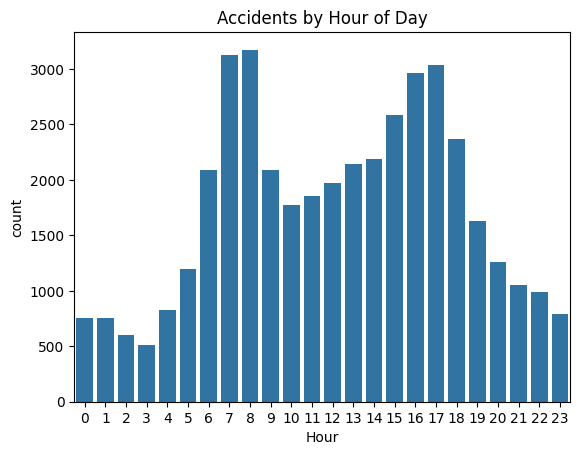

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Hour', data=df)
plt.title("Accidents by Hour of Day")
plt.show()

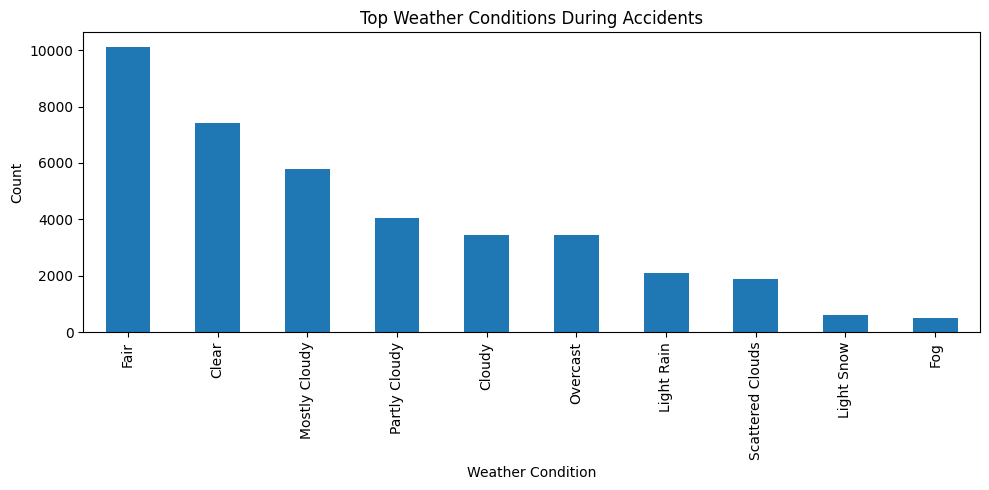

In [21]:
top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_weather.plot(kind='bar')

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("images/weather.png")
plt.show()

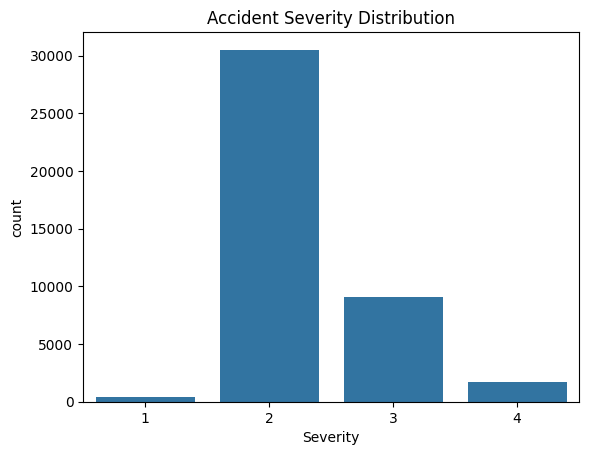

In [18]:
sns.countplot(x='Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()

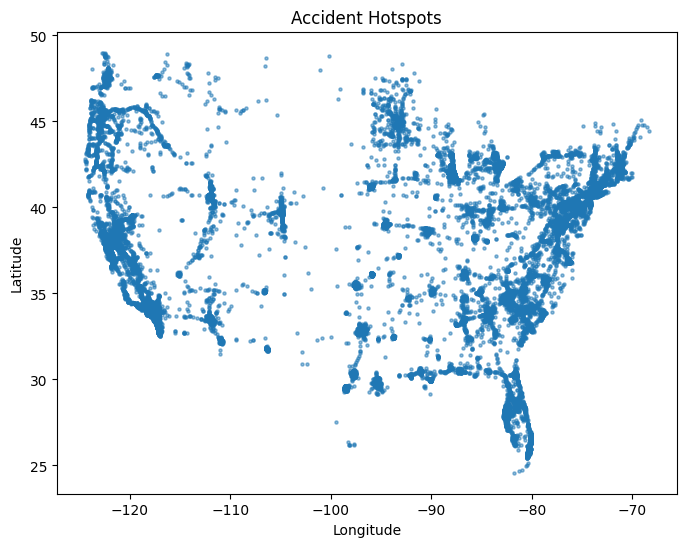

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(df['Start_Lng'], df['Start_Lat'], s=5, alpha=0.5)

plt.title("Accident Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

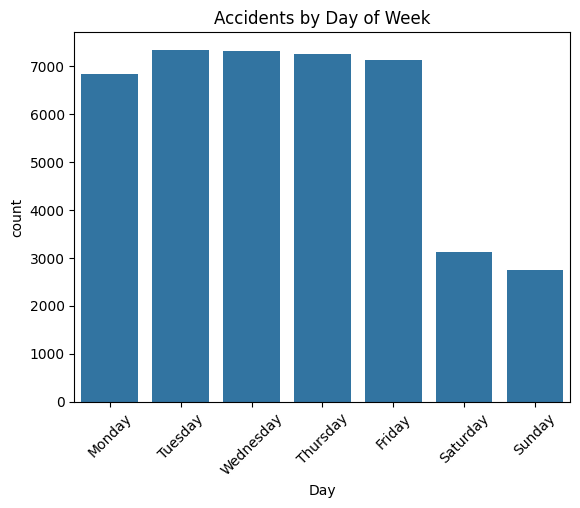

In [20]:
df['Day'] = df['Start_Time'].dt.day_name()

sns.countplot(x='Day', data=df, order=[
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.xticks(rotation=45)
plt.title("Accidents by Day of Week")
plt.show()